In [228]:
import numpy as np 
import Physical_Const as phys
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import brentq
from scipy.integrate import ode, odeint


#import WD.neutrinos as nunu
#import WD.CarbonFusion as eCC
#import WD.EoS_ionee as EOS
#import WD.ion_electron as ionee
#import WD.ions as ion
#import WD.electron_electron as ee
#import WD.Cv_star as cv


#----Constants------

hbar     = phys.hbar
c        = phys.c
G        = phys.G
SigmaSB    = phys.sigmaSB
me_mev   = phys.me
mp_mev   = phys.mp
e        = phys.e
e_erg    = phys.e_erg
mevtoerg = phys.mevtoerg
mu       = phys.mu 
kappaB   = phys.kappa
Msun     = phys.Msun
Rsun     = phys.Rsun

h        = hbar*(2.0*np.pi)
c2       = c*c
me       = me_mev * mevtoerg / c2
mp       = mp_mev * mevtoerg / c2

arad     = 4.0*SigmaSB / c
Tr       = me * c2 / kappaB
pi05     = np.sqrt(np.pi)
RBohr    = hbar**2 / (me*e_erg)
Lsun     = 3.846e33
yr       = (364)*24*60*60
avo      = 1.0 / mu


# ---Dimensions---
MA       = 2.0
Cgrav    = G * Msun / c**2
Jdim     = G / c**3

mpl      = np.sqrt(hbar * c / G) # planck mass
Rdim     = np.power( mpl / me , 2.0) * hbar / (mpl * c)
Mdim     = Rdim / Cgrav
Sigma02  = np.power( c / Rdim,2.0) / G

Sigma    = np.pi * me * np.power(me*c / h ,3.0) 
SigmaP   = c**2 * Sigma
rhodim   = ( ( mu * MA / me ) * 8.0* Sigma / 3.0 )
Tdim     = ( MA * mu *c2) / kappaB
Ldim     = 4.0 * np.pi * Rdim**2 * SigmaSB * Tdim**4
kappaK   = (4.34e24*Sigma02*Rdim)*Sigma02*np.power(Tdim,-3.5)
#Sigma02  = ( mu * MA / me ) * 8.0* Sigma / 3.0
#Rdim     = c / np.sqrt( Sigma02 * G )


Bdim     =  np.sqrt(G )  * Rdim / c2  
Jadim    = 1e50
JJdim    = Jadim * Jdim  / Rdim**2
rhobeta  = np.log10(3.9e10)


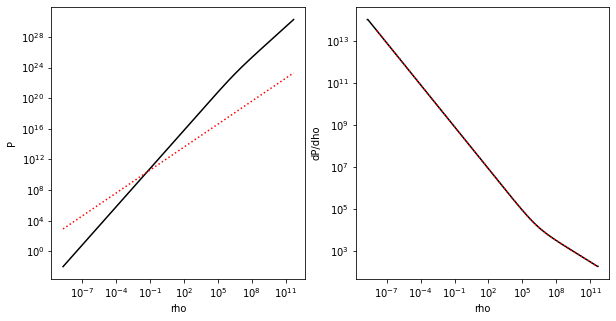

In [121]:
#---degenerate pressure-------------
def Pch_EoS(x):
    x2  = x*x
    
    if x > 2e-3:
        ww  = np.sqrt( 1.0 + x2) + x 
        pWD = x * np.sqrt( 1.0 + x2 ) * ( 2.0 * x2/3.0  - 1.0 ) +  np.log( ww ) 
    else:
        x3 = x2*x
        x5 = x3*x2
        x7 = x5*x2
        x9 = x7*x2
        x11 = x9*x2
        pWD = -2.77556e-17*x3 + 0.533333*x5 - 0.190476*x7 + 0.111111*x9 - 0.0757576*x11
    
    return SigmaP *pWD
   
def func(x):
    return  rhodim *np.power(x,3)

def DpDe_ch(x):
    x2   = x*x
    Dedx = 3.0 * rhodim * x**2
    Dpdx = SigmaP * 8.0 * x**4 / ( 3.0 * np.sqrt( 1.0 + x2 ) )
    
    return Dedx/Dpdx
    

NN      = 500
log_xXe = np.linspace( -5, 1.8,NN)
xx_xe   = np.power(10.0,log_xXe)

P_RFMT   = np.zeros(NN)
rho_RFMT = np.zeros(NN)
DeDp     = np.zeros(NN)
DeDp2    = np.zeros(NN)

for i in range(NN):
    xi          = xx_xe[i]
    P_RFMT[i]   = Pch_EoS(xi) / (c**2*Sigma02)
    rho_RFMT[i] = func(xi)  / Sigma02
    DeDp2[i]    = c**2*DpDe_ch(xi)

DxeF = 0.01
for i in range(NN):
    
    if i==0:
        Der = ( rho_RFMT[i+2] - rho_RFMT[0] ) / (  P_RFMT[i+2] - P_RFMT[0] )
    elif i== NN-1:
        Der = ( rho_RFMT[i] - rho_RFMT[i-2] ) / (  P_RFMT[i] - P_RFMT[i-2] )
    else:
        Der = ( rho_RFMT[i+1] - rho_RFMT[i-1] ) / (  P_RFMT[i+1] - P_RFMT[i-1] )
    
    DeDp[i] = Der

EoS_RFMT    = interp1d( rho_RFMT , P_RFMT , bounds_error=False)
EoS_RFMT_02 = interp1d( P_RFMT , rho_RFMT , bounds_error=False)
DeDpF       = interp1d( P_RFMT , DeDp2 , bounds_error=False)

fig= plt.figure( figsize = ( 10, 5 ) )

plt.subplot(121)
plt.loglog( Sigma02 * rho_RFMT, Sigma02*c**2*P_RFMT,'k-')
plt.loglog( Sigma02 * rho_RFMT, Sigma02*c**2*(rho_RFMT*(1e4/Tdim)),'r:')
plt.xlabel("rho")
plt.ylabel("P")

plt.subplot(122)
plt.loglog( Sigma02 * rho_RFMT[:], DeDp[:],'k-')
plt.loglog( Sigma02 * rho_RFMT[20:], DeDp2[20:],'r:')

plt.xlabel("rho")
plt.ylabel("dP/dho")
plt.show()

plt.show()



In [241]:
def Magnetic(rho, Bs, B0):
    rho0    = 1e9 /  Sigma02
    x       = rho / rho0
    eta     = 0.8
    gamma   = 0.9
    
    Bfield  = Bs + B0*( 1.0 - np.exp( -eta * x**gamma ) )
    DBfield =  B0 *  np.exp( -eta * x**gamma )  * ( eta * gamma * x**(gamma - 1.0) ) / rho0
    
    return  [ Bfield, DBfield ]

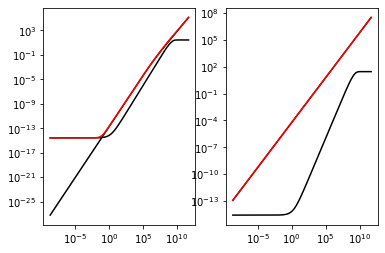

In [242]:
bb = Magnetic( rho_RFMT, 1e6*Bdim, 1e14*Bdim)

plt.subplot(121)
plt.loglog( Sigma02 * rho_RFMT, bb[0]**2/(8.0*np.pi),'k-')
plt.loglog( Sigma02 * rho_RFMT,  P_RFMT,'k-')

plt.loglog( Sigma02 * rho_RFMT, bb[0]**2/(8.0*np.pi)+  P_RFMT,'r-')

plt.subplot(122)
plt.loglog( Sigma02 * rho_RFMT, bb[0]**2/(8.0*np.pi),'k-')
plt.loglog( Sigma02 * rho_RFMT,  rho_RFMT,'k-')
plt.loglog( Sigma02 * rho_RFMT,  rho_RFMT + bb[0]**2/(8.0*np.pi),'r-')

In [243]:
def TOV(r,y, Bs, B0):
    mns   = y[0]
    rhons = y[1]
    nuns  = y[2]
    
    pns =  EoS_RFMT(rhons)
    dPdrho = 1.0/DeDpF(pns)
    BB     = Magnetic(rhons, Bs, B0)
    BB2    = BB[0]**2
    PB     = BB2 /( 8.0*np.pi )
    rhoB   = BB2 / ( 8.0*np.pi )
    Dbdrho = BB[0]*BB[1] / ( 4.0*np.pi  )

    rhostar = rhons + rhoB

    r2   = r*r
    r3   = r2*r
    ec1  = 4.0 * np.pi * r2 * rhostar
    ec2  = 2.0 * ( 4.0 * np.pi * r3 * ( pns + PB ) + mns ) / ( r * ( r - 2.0 * mns ) )
    
    ec3  = -0.5 * ec2 * ( pns + PB + rhostar ) / ( Dbdrho + dPdrho )
    
    return np.array( [ec1,ec3,ec2])


In [244]:
WDmag = ode(TOV).set_integrator('dopri5')

#----Loop to calculate Static sequence--------

def StaticSeq(y0,r0, drr,rf, Bss, B00 ):
    global pwd, rhowd, rr
    #r0 = drr*1e-2

    pwd   = [ ]
    rhowd = [ ]
    rr    = [ ]
   
    WDmag.set_initial_value(y0,r0).set_f_params( Bss,B00)

    while WDmag.successful() and WDmag.t<rf and WDmag.y[1]*Sigma02 > 1e-8 and WDmag.y[1]>0.0:

        WDmag.integrate(WDmag.t+drr) 

        rhowd.append( WDmag.y[1] )
        pwd.append( EoS_RFMT( WDmag.y[1]) )
        rr.append( WDmag.t )
      
        rstar = WDmag.t
        mstar = WDmag.y[0]
    
    #print(WDmag.successful(), WDmag.y[0],WDmag.y[1], TOV(WDmag.t,WDmag.y, Bs,B0))
    
    return [mstar,rstar]

In [256]:
rf = 1.0
dr = 1e-7
r0 = dr

rholog = np.arange( 4.5, 10.5, 0.3 )
rhoc = np.power(10.0, rholog) / Sigma02 
pc   = EoS_RFMT( rhoc )

Nm   = len(rhoc)

Bwd = [ [0,0], [1e9,1e13],[1e7, 1e14],[1e9, 1e14]]
StarWD = np.zeros((len(Bwd),2,Nm))
for j in range(len(Bwd)): 
    Bs = Bwd[j][0] * Bdim
    B0 = Bwd[j][1] * Bdim
    print(Bs,B0)
    for i in range(Nm):
      
        m00 = 0.0#( 4.0 / 3.0 ) * np.pi * (r0)**3 * np.power(10.0,rhoc[i])/Sigma02
        M1 = StaticSeq([m00, rhoc[i], 0.0], r0, dr, rf, Bs, B0)
        StarWD[j,0,i] = M1[0]
        StarWD[j,1,i] = M1[1]

0.0 0.0


/tmp/ipykernel_61824/3952859294.py:7: RuntimeWarning: invalid value encountered in scalar power
  Bfield  = Bs + B0*( 1.0 - np.exp( -eta * x**gamma ) )
/tmp/ipykernel_61824/3952859294.py:8: RuntimeWarning: invalid value encountered in scalar power
  DBfield =  B0 *  np.exp( -eta * x**gamma )  * ( eta * gamma * x**(gamma - 1.0) ) / rho0


0.0002652053385885254 2.652053385885254
2.652053385885254e-06 26.520533858852538
0.0002652053385885254 26.520533858852538


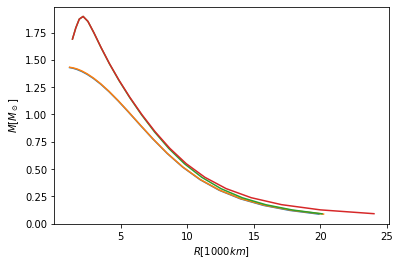

In [257]:
for j in range(len(Bwd)): 
    plt.plot(StarWD[j,1,:]*Rdim*1e-8, StarWD[j,0,:]*Mdim, "-")

plt.ylabel("$M [M_\\odot]$")
plt.xlabel("$R [1000 km]$")

plt.show()